In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [57]:
df=pd.read_csv("student_performance_simple_500.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'student_performance_simple_500.csv'

In [3]:
df.head()

,Attendance,Study_Hours,Marks,Final_Performance
0,70.0,3.0,44.0,Poor
1,91.0,1.0,30.0,Poor
2,84.0,2.0,42.0,Poor
3,87.0,1.0,42.0,Poor
4,63.0,1.0,30.0,Poor


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Attendance         500 non-null    float64
 1   Study_Hours        500 non-null    float64
 2   Marks              500 non-null    float64
 3   Final_Performance  505 non-null    object 
dtypes: float64(3), object(1)
memory usage: 15.9+ KB


In [5]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
500     True
501     True
502     True
503     True
504     True
Length: 505, dtype: bool

In [6]:
df.shape

(505, 4)

In [7]:
df.columns

Index(['Attendance', 'Study_Hours', 'Marks', 'Final_Performance'], dtype='object')

In [8]:
df.describe()

,Attendance,Study_Hours,Marks
count,500.000000,500.000000,500.000000
mean,73.884000,4.394000,52.084000
std,14.669729,2.286749,15.016789
min,50.000000,1.000000,30.000000
25%,61.000000,2.000000,40.000000
50%,73.000000,4.000000,52.000000
75%,86.000000,6.000000,64.000000
max,100.000000,8.000000,88.000000


In [9]:
df.isna().sum()

Attendance           5
Study_Hours          5
Marks                5
Final_Performance    0
dtype: int64

# EDA

([<matplotlib.patches.Wedge at 0x15306d430e0>,
 [Text(-0.17376735321812542, 1.0861882465556176, 'Poor'),
  Text(-0.333403796411671, -1.0482566043380244, 'Average'),
  Text(0.9665629585291843, -0.5251247920250106, 'Good'),
  Text(1.0994679109009151, -0.03420983629276139, 'Excellent')],
 [Text(-0.09478219266443204, 0.5924663163030641, '55.0%'),
  Text(-0.18185661622454782, -0.5717763296389223, '30.1%'),
  Text(0.5272161591977368, -0.28643170474091484, '13.9%'),
  Text(0.5997097695823173, -0.018659910705142575, '1.0%')])

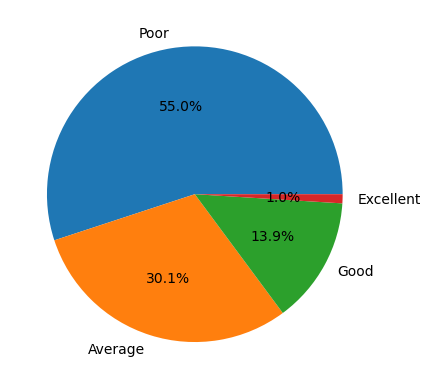

In [10]:
#class Distribution

plt.pie(df["Final_Performance"].value_counts(),autopct="%1.1f%%",labels=df["Final_Performance"].value_counts().index)

Text(0.5, 0, 'Marks')

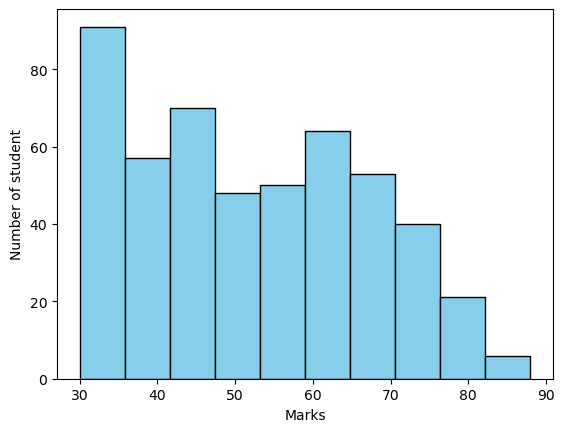

In [11]:
# Marks Distribution
plt.hist(df["Marks"],color="skyblue",edgecolor="black",bins=10)# bins 5 mean data devided in to 5 ranges
plt.ylabel("Number of student")
plt.xlabel("Marks")


Text(0.5, 0, 'Attendance in %')

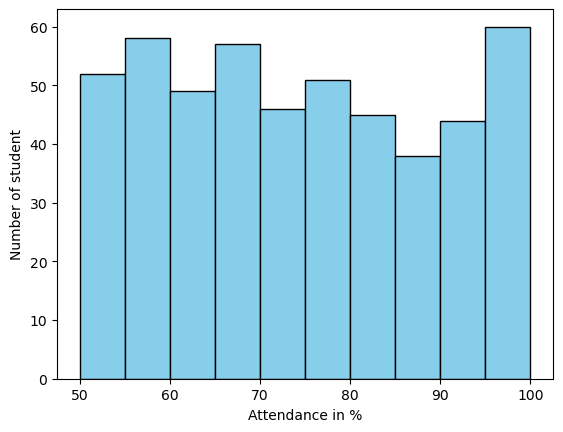

In [12]:
# Attendance Distribution
plt.hist(df["Attendance"],color="skyblue",edgecolor="black",bins=10)
plt.ylabel("Number of student")
plt.xlabel("Attendance in %")

Text(0.5, 0, 'Study Hours')

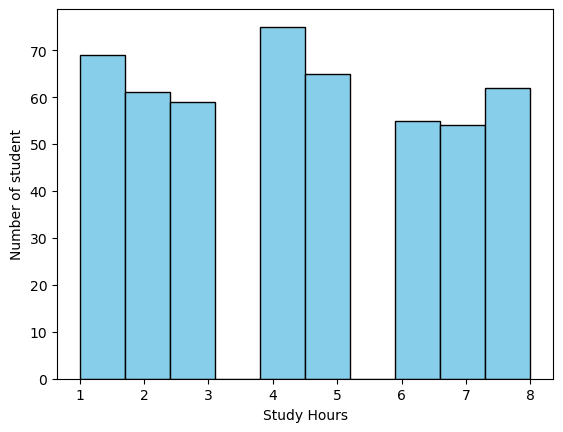

In [13]:
#Study_hours Distribution
plt.hist(df["Study_Hours"],color="skyblue",edgecolor="black",bins=10)
plt.ylabel("Number of student")
plt.xlabel("Study Hours")

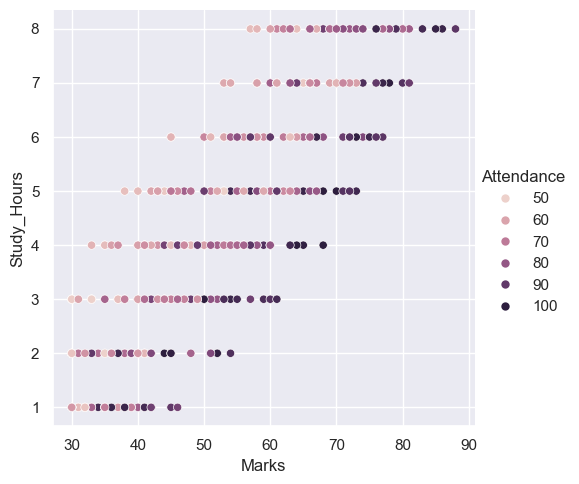

In [14]:
# Marks Vs Attendance

sns.set_theme(style="darkgrid") 
sns.relplot(
    data=df,
    x="Marks",
    y="Study_Hours",
    hue="Attendance"
)

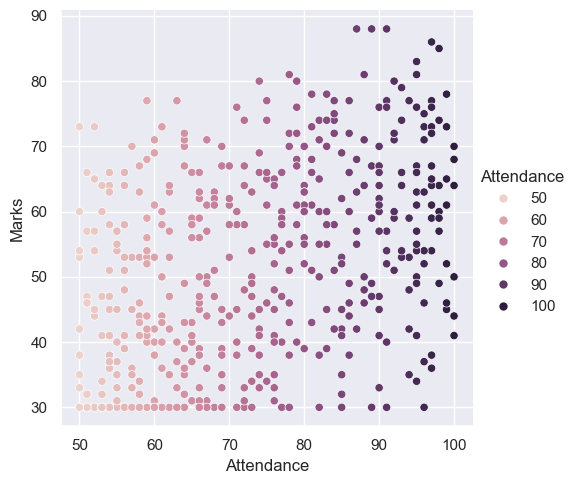

In [15]:
# Attendance vs Marks
sns.set_theme(style="darkgrid") 
sns.relplot(
    data=df,
    x="Attendance",
    y="Marks",
    hue="Attendance"
)

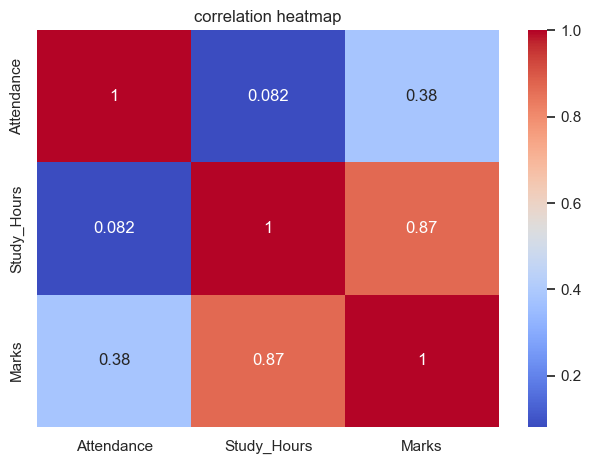

In [16]:
# Correlation heatmap
cor=df.corr(numeric_only=True)
sns.heatmap(
    cor,
    cmap="coolwarm",
    annot=True,
    
)
plt.title("correlation heatmap")
plt.tight_layout()
plt.show()

# Data Cleaning and Preprocessing

In [17]:
# Handling  Missing values
df.isna().sum()

Attendance           5
Study_Hours          5
Marks                5
Final_Performance    0
dtype: int64

In [18]:
df["Attendance"]=df["Attendance"].fillna(df["Attendance"].mean())

In [19]:
df["Study_Hours"]=df["Study_Hours"].fillna(df["Study_Hours"].mean())

In [20]:
df["Marks"]=df["Marks"].fillna(df["Marks"].mean())

In [21]:
df.isna().sum()

Attendance           0
Study_Hours          0
Marks                0
Final_Performance    0
dtype: int64

In [22]:
# Handling Duplicate values
df.duplicated().sum()

np.int64(25)

In [23]:
df=df.drop_duplicates()

In [24]:
df.duplicated().sum()
df["Final_Performance"].unique()

array(['Poor', 'Average', 'Good', 'Excellent'], dtype=object)

# Encoding

In [25]:
le=LabelEncoder()
df["Final_Performance"]=le.fit_transform(df["Final_Performance"])

In [26]:
df.head()

,Attendance,Study_Hours,Marks,Final_Performance
0,70.0,3.0,44.0,3
1,91.0,1.0,30.0,3
2,84.0,2.0,42.0,3
3,87.0,1.0,42.0,3
4,63.0,1.0,30.0,3


# Featuresv selection

In [27]:
x=df.drop("Final_Performance",axis=1)
y=df["Final_Performance"]

# Train Test Split

In [40]:
x_train, x_test ,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Model Training 

In [41]:
model=DecisionTreeClassifier(max_depth=2)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred=model.predict(x_test)

In [43]:
print("accuracy_score is:",accuracy_score(y_test,y_pred)*100)


accuracy_score is: 98.95833333333334


In [44]:
print("confusion matrix is :\n",confusion_matrix(y_test,y_pred))

confusion matrix is :
 [[30  0  0  0]
 [ 0  0  1  0]
 [ 0  0 13  0]
 [ 0  0  0 52]]


In [45]:
print("classification Report :")
print(classification_report(y_test,y_pred,zero_division=0))

classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.00      0.00      0.00         1
           2       0.93      1.00      0.96        13
           3       1.00      1.00      1.00        52

    accuracy                           0.99        96
   macro avg       0.73      0.75      0.74        96
weighted avg       0.98      0.99      0.98        96



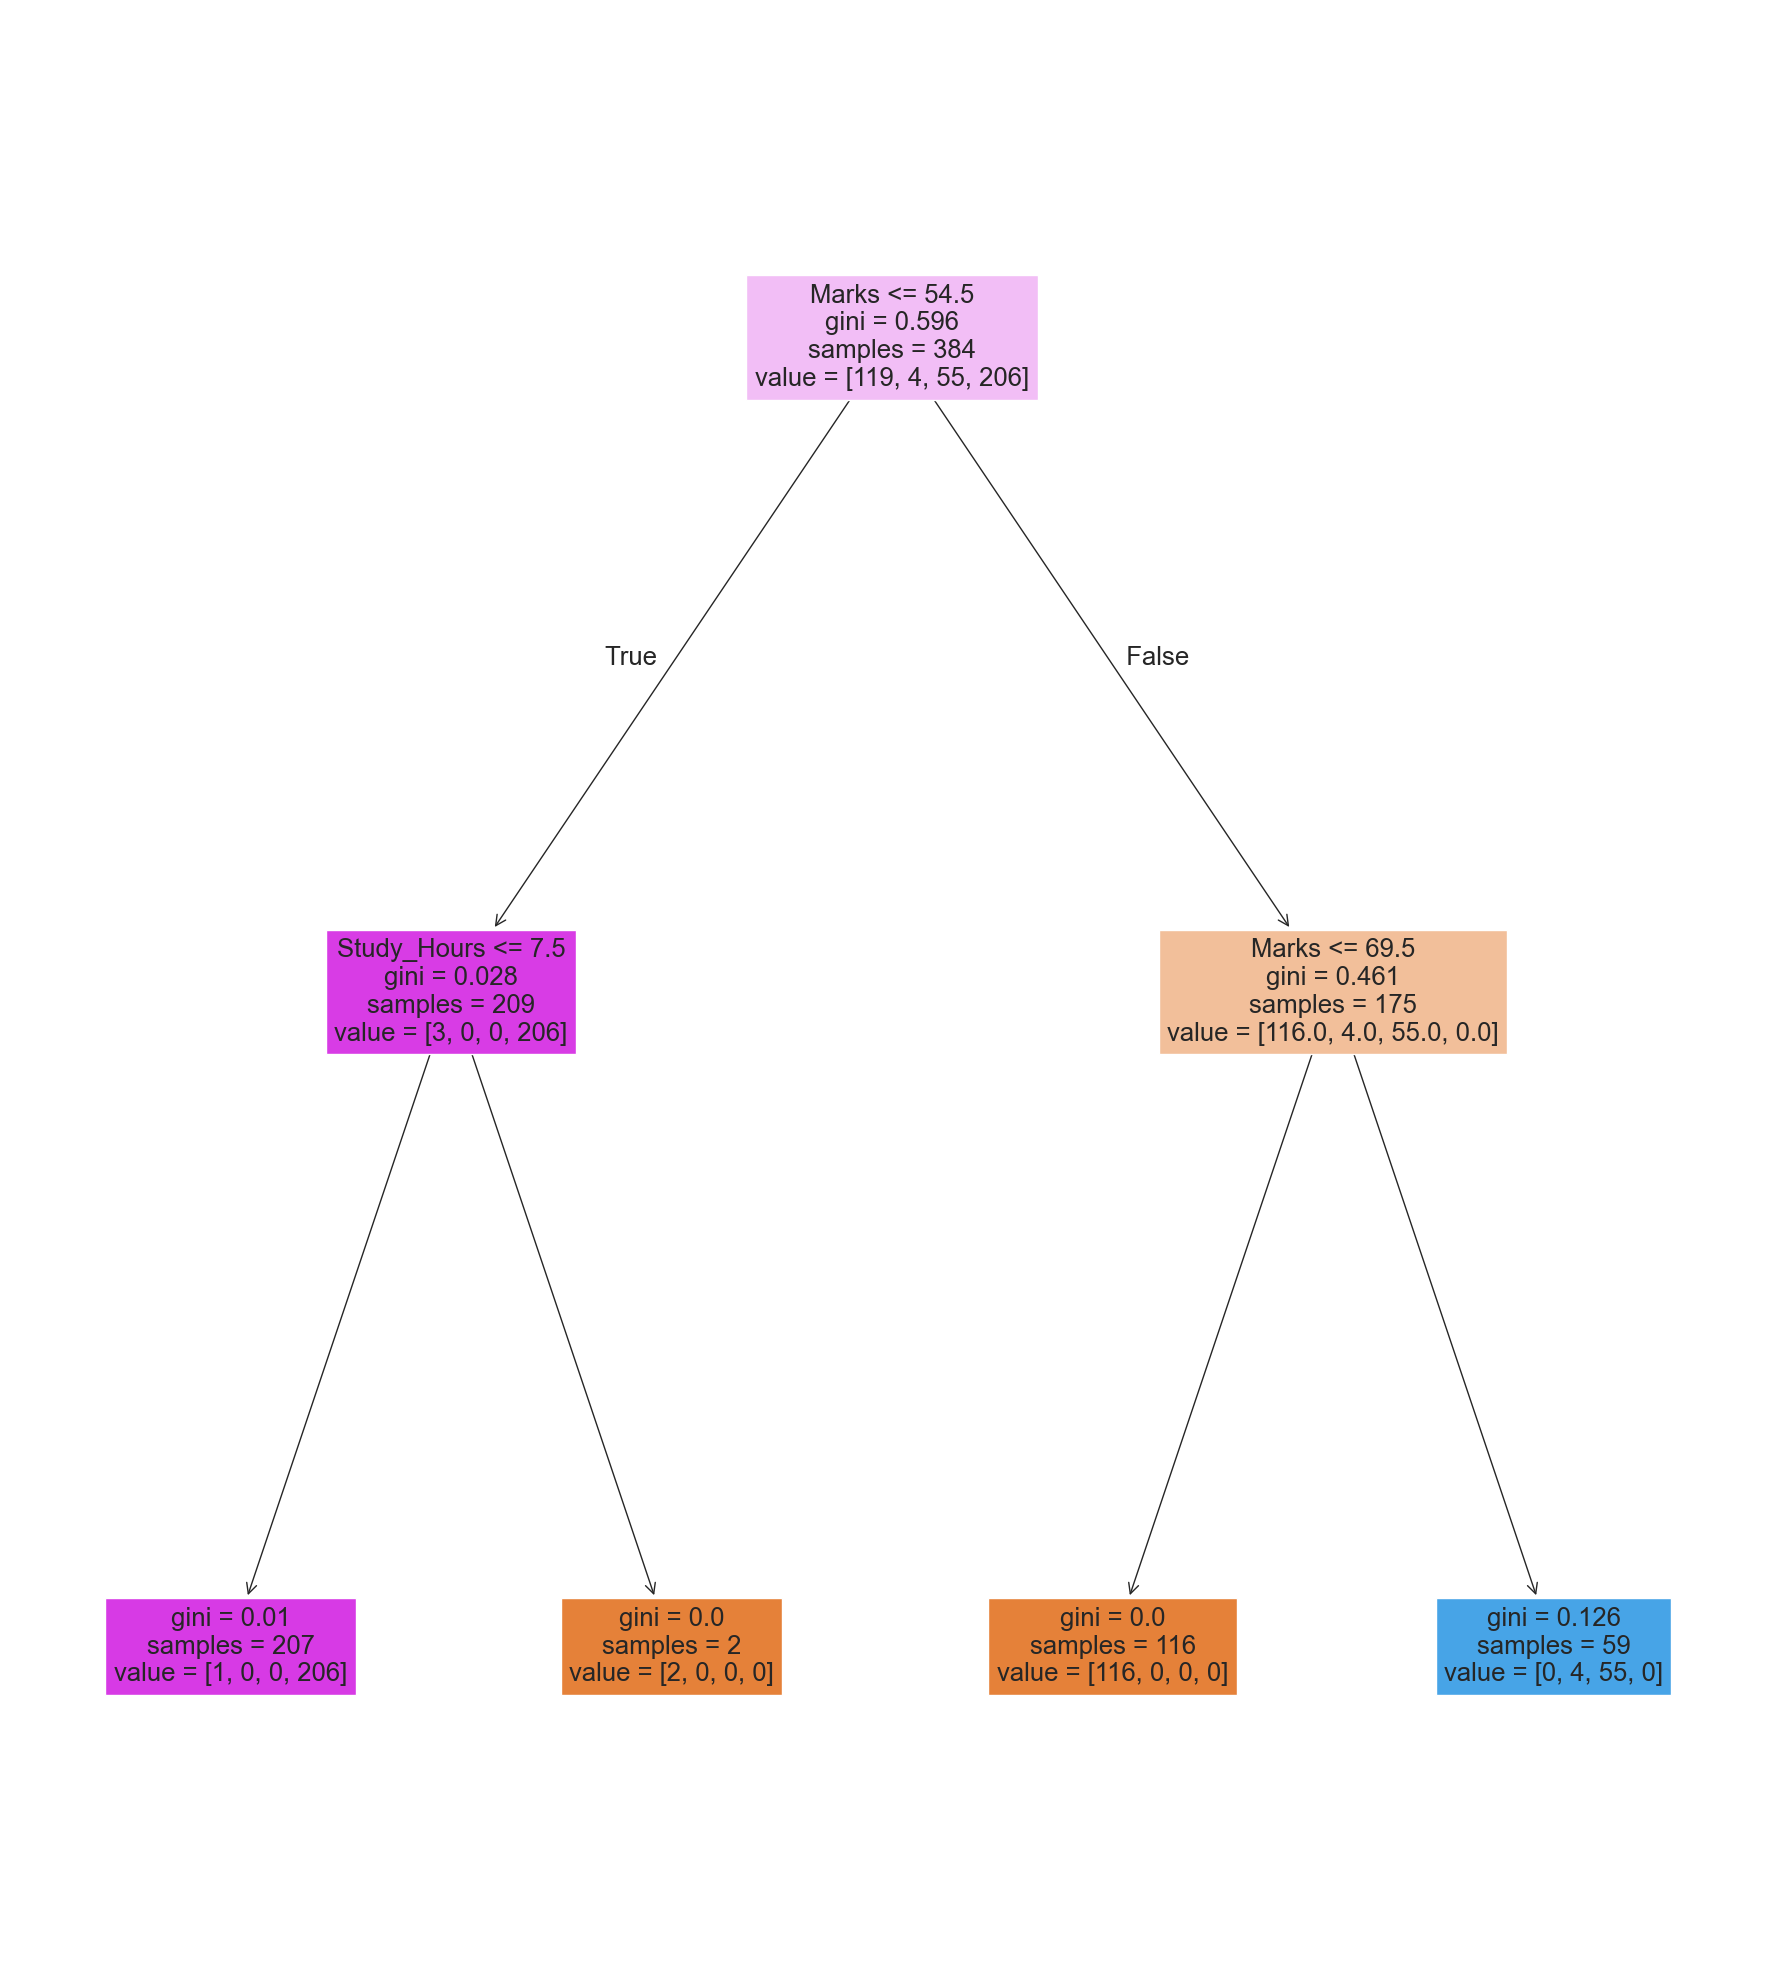

In [46]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,20))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True,
)
plt.tight_layout()
plt.show()

# User  input

In [47]:
attendance=float(input("Enter Attendance (%):"))
study_hours=float(input("Enter Study_hours :"))
marks=float(input("Enter marks:"))
user_data=pd.DataFrame([[attendance,study_hours,marks]],columns=x.columns)
prediction =model.predict(user_data)
reults=le.inverse_transform(prediction)
print("Predicted Performance :",reults[0])

Enter Attendance (%): 80
Enter Study_hours : 9
Enter marks: 90


Predicted Performance : Good
